# EDA: Work Operation Co-occurrence Analysis

This notebook analyzes which work operations tend to occur together within the same project.

**Key Questions:**
1. Which work operation clusters frequently appear together in the same project?
2. Are there groups of operations that always occur together?
3. What are the most common operation pairs/triplets?
4. Can we identify operation "bundles" or patterns?

**Sections:**
- Import libraries
- Load and prepare data
- Co-occurrence matrix (project-level)
- Pairwise co-occurrence analysis
- Association rules and lift scores
- Network analysis of co-occurrences
- Room-level co-occurrence patterns
- Visualization and insights

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from IPython.display import display

## Load and Prepare Data

Load train.csv (and optionally val.csv) to analyze co-occurrence patterns within projects.

In [2]:
# Load train data
train_path = "../data/hackathon-recover-x-cogito/train.csv"
train = pd.read_csv(train_path)

print('Train shape:', train.shape)
print('Columns:', train.columns.tolist())
display(train.head())

# Basic stats
print(f'\nUnique projects: {train["project_id"].nunique()}')
print(f'Unique operation clusters: {train["work_operation_cluster_code"].nunique()}')
print(f'Unique rooms: {train["room"].nunique() if "room" in train.columns else "N/A"}')

Train shape: (1908899, 5)
Columns: ['id', 'project_id', 'room', 'work_operation_cluster_name', 'work_operation_cluster_code']


,id,project_id,room,work_operation_cluster_name,work_operation_cluster_code
0,18299,197011,tilkomstvei,Lett beskyttelse av gulv med dekkepapp,256
1,18299,197011,tilkomstvei,Byggvask,108
2,18299,197011,tilkomstvei,Tildekking av trappetrinn,260
3,18300,270183,Bar,Ny underlag for parkett/laminat,53
4,18300,270183,Bar,Demont gulvlist for gjenbruk,67



Unique projects: 51009
Unique operation clusters: 368
Unique rooms: 15347


## Project-Level Co-occurrence Matrix

Build a co-occurrence matrix showing how often each pair of operations appears in the same project.

In [3]:
# Get unique operations per project (ignoring counts for now)
project_operations = train.groupby('project_id')['work_operation_cluster_code'].apply(lambda x: set(x)).reset_index()
project_operations.columns = ['project_id', 'operations']

print(f'Total projects: {len(project_operations)}')
print(f'Sample project operations:')
display(project_operations.head())

# Build co-occurrence matrix
# For each project, find all pairs of operations that occur together
cooccurrence_counts = Counter()

for ops in project_operations['operations']:
    if len(ops) > 1:
        # Get all pairs of operations in this project
        pairs = list(combinations(sorted(ops), 2))
        cooccurrence_counts.update(pairs)

print(f'\nTotal unique operation pairs: {len(cooccurrence_counts)}')
print(f'Top 20 most common pairs:')
top_pairs = pd.DataFrame(cooccurrence_counts.most_common(20), columns=['pair', 'count'])
display(top_pairs)

Total projects: 51009
Sample project operations:


,project_id,operations
0,147474,"{256, 260, 5, 6, 7, 11, 151, 152, 157, 158, 16..."
1,147481,"{3, 4, 5, 6, 7, 10, 11, 44, 45, 46, 49, 52, 53..."
2,147483,"{256, 66, 258, 132, 133, 70, 44, 46, 49, 52, 5..."
3,147485,"{256, 129, 128, 136, 137, 138, 204, 108, 125, ..."
4,147486,"{256, 288, 2, 3, 386, 358, 263, 296, 294, 10, ..."



Total unique operation pairs: 60436
Top 20 most common pairs:


,pair,count
0,"(108, 256)",28442
1,"(108, 204)",26603
2,"(49, 70)",24624
3,"(204, 256)",24481
4,"(46, 53)",20963
5,"(44, 46)",20885
6,"(46, 70)",20516
7,"(44, 52)",20483
8,"(46, 108)",20350
9,"(70, 108)",19989


## Visualize Co-occurrence Matrix

Create a heatmap showing the most common operation co-occurrences.

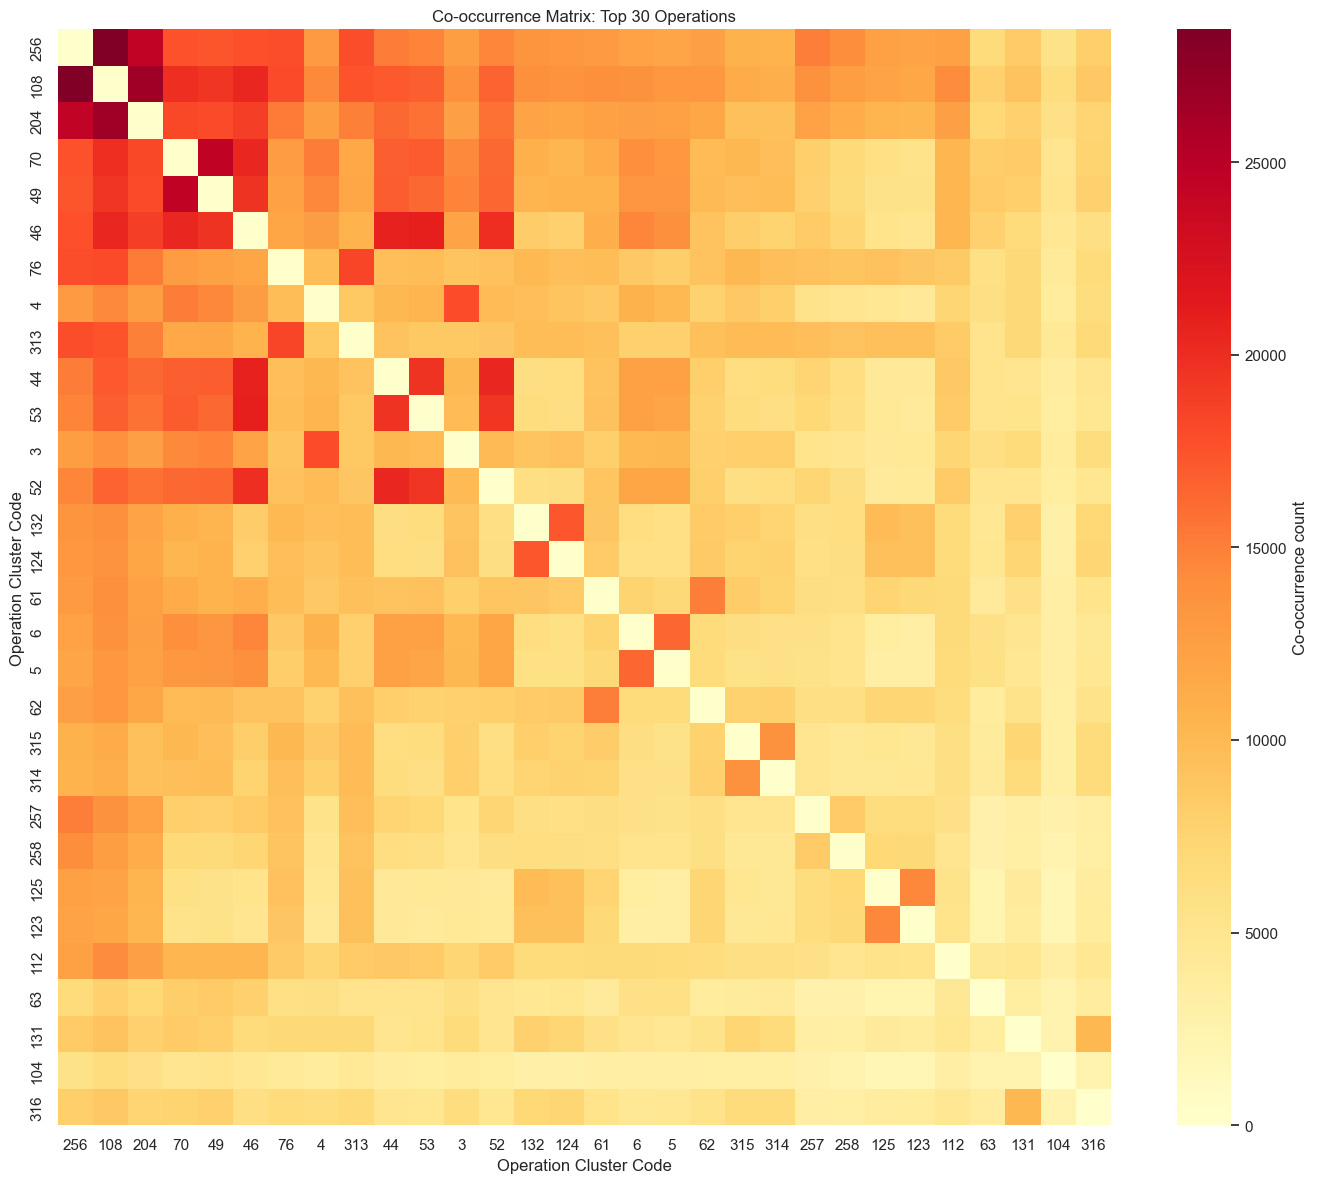

Diagonal should be 0: 0


In [4]:
# Build a symmetric co-occurrence matrix for the top operations
# Select top N operations by frequency
top_n = 30
top_ops = train['work_operation_cluster_code'].value_counts().head(top_n).index.tolist()

# Initialize matrix
cooc_matrix = pd.DataFrame(0, index=top_ops, columns=top_ops)

# Fill matrix with co-occurrence counts
for (op1, op2), count in cooccurrence_counts.items():
    if op1 in top_ops and op2 in top_ops:
        cooc_matrix.loc[op1, op2] = count
        cooc_matrix.loc[op2, op1] = count  # symmetric

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cooc_matrix, cmap='YlOrRd', annot=False, fmt='d', cbar_kws={'label': 'Co-occurrence count'})
plt.title(f'Co-occurrence Matrix: Top {top_n} Operations')
plt.xlabel('Operation Cluster Code')
plt.ylabel('Operation Cluster Code')
plt.tight_layout()
plt.show()

# Show diagonal (self co-occurrence, should be 0 since we only count pairs)
print('Diagonal should be 0:', cooc_matrix.values.diagonal().sum())

## Association Rules: Lift and Support

Calculate lift scores to find operations that co-occur more often than expected by chance.

- **Support**: Fraction of projects containing both operations
- **Confidence**: P(B|A) = P(A and B) / P(A)
- **Lift**: P(A and B) / (P(A) * P(B)) - measures how much more likely B occurs given A, compared to B occurring independently

In [5]:
# Calculate support, confidence, and lift for operation pairs
total_projects = len(project_operations)

# Get individual operation counts (support for single operation)
op_counts = train.groupby('work_operation_cluster_code')['project_id'].nunique().to_dict()

# Calculate metrics for each pair
association_metrics = []

for (op1, op2), cooc_count in cooccurrence_counts.items():
    support_AB = cooc_count / total_projects
    support_A = op_counts.get(op1, 0) / total_projects
    support_B = op_counts.get(op2, 0) / total_projects
    
    # Confidence: P(B|A) and P(A|B)
    conf_A_to_B = cooc_count / op_counts.get(op1, 1) if op_counts.get(op1, 0) > 0 else 0
    conf_B_to_A = cooc_count / op_counts.get(op2, 1) if op_counts.get(op2, 0) > 0 else 0
    
    # Lift: how much more likely they occur together than independently
    lift = support_AB / (support_A * support_B) if (support_A * support_B) > 0 else 0
    
    association_metrics.append({
        'op1': op1,
        'op2': op2,
        'cooc_count': cooc_count,
        'support': support_AB,
        'confidence_A_to_B': conf_A_to_B,
        'confidence_B_to_A': conf_B_to_A,
        'lift': lift
    })

assoc_df = pd.DataFrame(association_metrics)

# Filter for meaningful associations (lift > 1 means positive association)
# and reasonable support (at least 1% of projects)
meaningful = assoc_df[(assoc_df['lift'] > 1.5) & (assoc_df['support'] > 0.01)].sort_values('lift', ascending=False)

print(f'Total pairs: {len(assoc_df)}')
print(f'Pairs with lift > 1.5 and support > 1%: {len(meaningful)}')
print('\nTop 30 strongest associations (by lift):')
display(meaningful.head(30))

Total pairs: 60436
Pairs with lift > 1.5 and support > 1%: 2439

Top 30 strongest associations (by lift):


,op1,op2,cooc_count,support,confidence_A_to_B,confidence_B_to_A,lift
11173,273,275,599,0.011743,0.783007,0.896707,59.790989
9738,193,195,745,0.014605,0.887962,0.909646,55.304086
10887,271,274,749,0.014684,0.785115,0.928129,49.625708
10878,270,272,722,0.014154,0.814898,0.835648,48.110131
8635,96,344,685,0.013429,0.819378,0.735768,44.893289
2976,191,197,679,0.013311,0.714737,0.833129,44.733757
9021,23,24,1011,0.019820,0.912455,0.930083,42.818225
21634,87,91,921,0.018056,0.788527,0.966422,42.205660
10324,50,71,687,0.013468,0.716371,0.763333,40.601533
11163,270,273,532,0.010430,0.600451,0.695425,40.037162


## Visualize Association Strength

Plot scatter: support vs lift, colored by co-occurrence count.

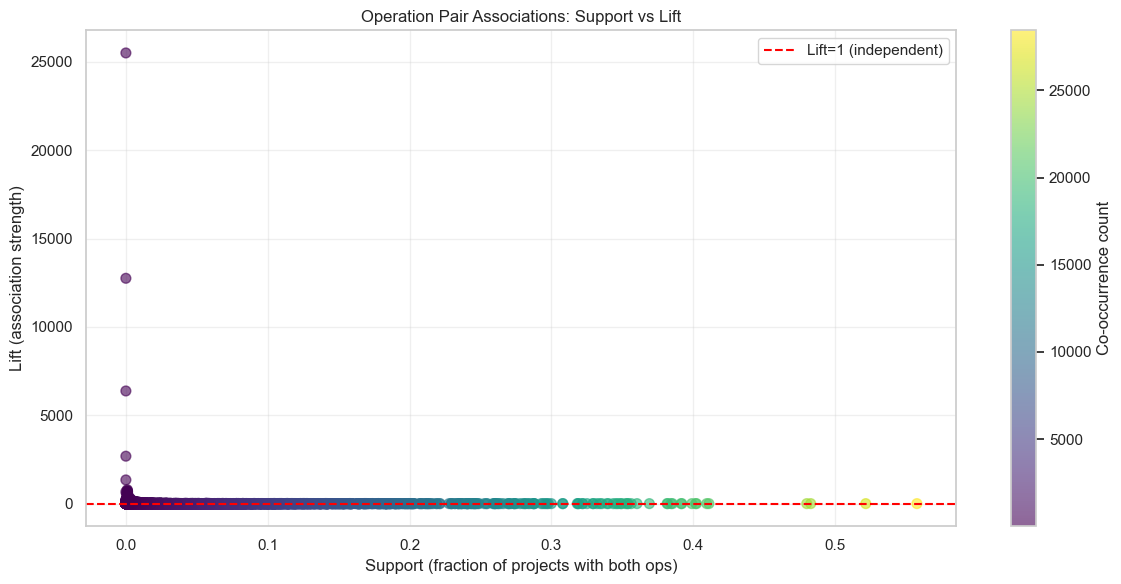

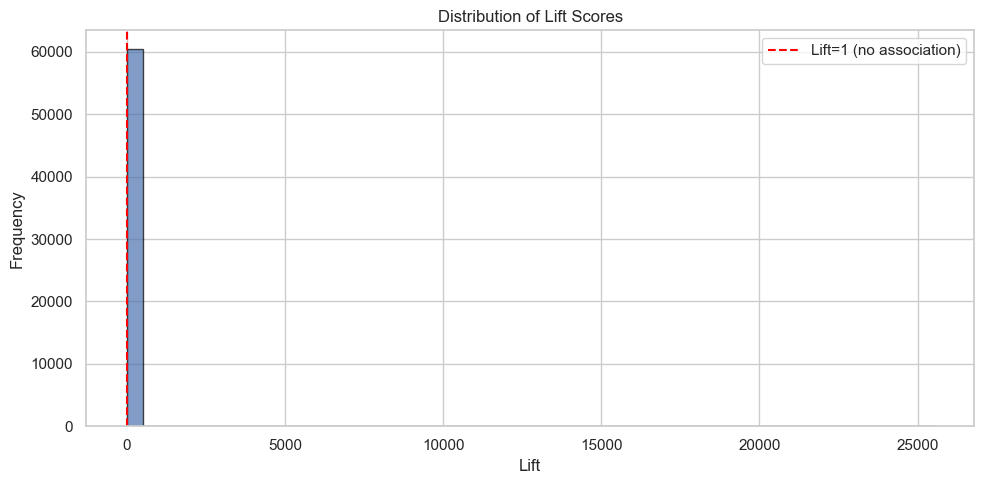

In [6]:
# Scatter plot: support vs lift
plt.figure(figsize=(12, 6))
scatter = plt.scatter(assoc_df['support'], assoc_df['lift'], 
                      c=assoc_df['cooc_count'], s=50, alpha=0.6, cmap='viridis')
plt.colorbar(scatter, label='Co-occurrence count')
plt.xlabel('Support (fraction of projects with both ops)')
plt.ylabel('Lift (association strength)')
plt.title('Operation Pair Associations: Support vs Lift')
plt.axhline(y=1, color='red', linestyle='--', label='Lift=1 (independent)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Histogram of lift scores
plt.figure(figsize=(10, 5))
plt.hist(assoc_df['lift'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Lift')
plt.ylabel('Frequency')
plt.title('Distribution of Lift Scores')
plt.axvline(x=1, color='red', linestyle='--', label='Lift=1 (no association)')
plt.legend()
plt.tight_layout()
plt.show()

## Network Analysis of Co-occurrences

Build a network graph where nodes are operations and edges represent co-occurrence strength.

Network nodes: 138
Network edges: 580


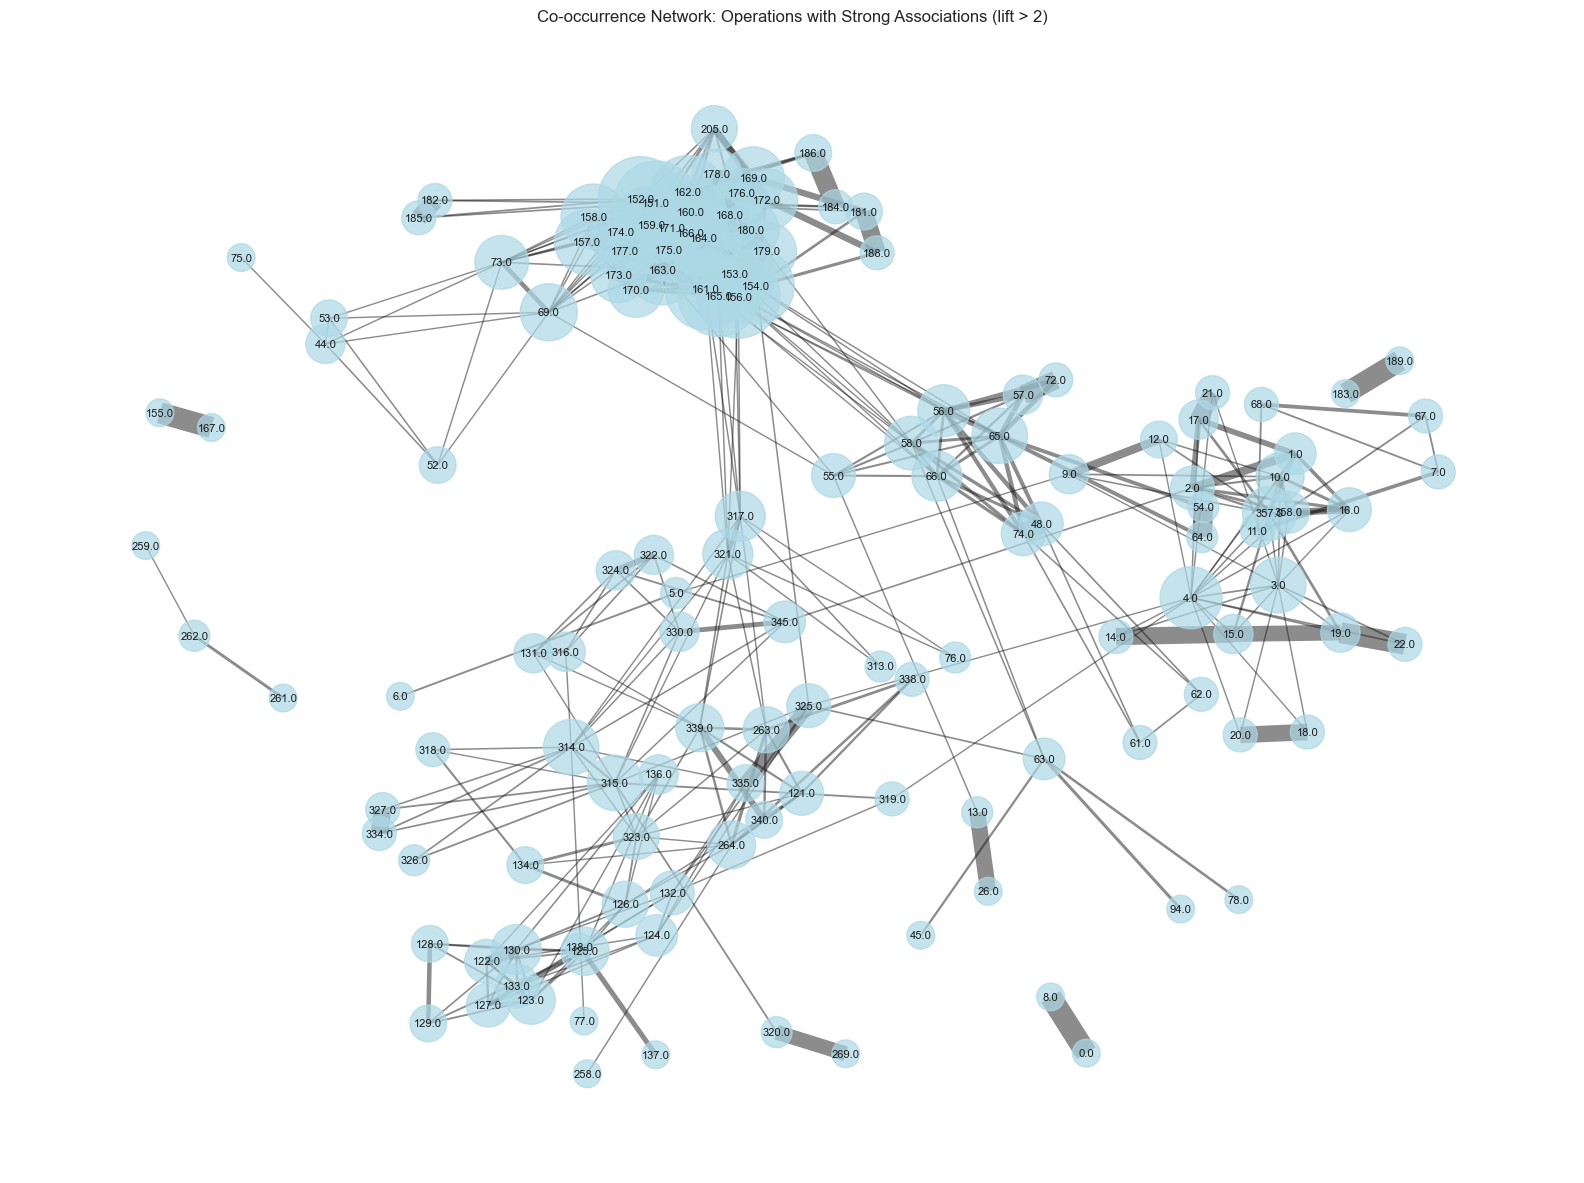


Detected 12 communities:
Community 1: [np.float64(69.0), np.float64(73.0), np.float64(151.0), np.float64(152.0), np.float64(153.0), np.float64(154.0), np.float64(157.0), np.float64(158.0), np.float64(159.0), np.float64(160.0), np.float64(161.0), np.float64(162.0), np.float64(163.0), np.float64(164.0), np.float64(165.0), np.float64(166.0), np.float64(168.0), np.float64(169.0), np.float64(170.0), np.float64(171.0), np.float64(172.0), np.float64(173.0), np.float64(174.0), np.float64(175.0), np.float64(176.0), np.float64(177.0), np.float64(178.0), np.float64(179.0), np.float64(180.0), np.float64(181.0), np.float64(182.0), np.float64(184.0), np.float64(185.0), np.float64(186.0), np.float64(188.0), np.float64(205.0)]
Community 2: [np.float64(76.0), np.float64(77.0), np.float64(121.0), np.float64(126.0), np.float64(131.0), np.float64(134.0), np.float64(258.0), np.float64(263.0), np.float64(264.0), np.float64(269.0), np.float64(313.0), np.float64(314.0), np.float64(315.0), np.float64(316.0), 

In [7]:
# Build network graph using networkx (install if needed)
try:
    import networkx as nx
    
    # Create graph from top associations
    G = nx.Graph()
    
    # Add edges for strong associations (lift > 2, support > 0.02)
    strong_assoc = assoc_df[(assoc_df['lift'] > 2) & (assoc_df['support'] > 0.02)]
    
    for _, row in strong_assoc.iterrows():
        G.add_edge(row['op1'], row['op2'], weight=row['lift'], count=row['cooc_count'])
    
    print(f'Network nodes: {G.number_of_nodes()}')
    print(f'Network edges: {G.number_of_edges()}')
    
    # Draw network
    plt.figure(figsize=(16, 12))
    pos = nx.spring_layout(G, k=0.5, iterations=50)
    
    # Node sizes based on degree (how many connections)
    node_sizes = [300 + 100 * G.degree(node) for node in G.nodes()]
    
    # Edge widths based on lift
    edge_widths = [G[u][v]['weight'] * 0.5 for u, v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5)
    
    plt.title('Co-occurrence Network: Operations with Strong Associations (lift > 2)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Identify clusters/communities
    from networkx.algorithms import community
    communities = list(community.greedy_modularity_communities(G))
    print(f'\nDetected {len(communities)} communities:')
    for i, comm in enumerate(communities[:10], 1):
        print(f'Community {i}: {sorted(list(comm))}')
        
except ImportError:
    print('NetworkX not installed. Run: pip install networkx')
    print('Skipping network analysis.')

## Room-Level Co-occurrence Analysis

Analyze which operations tend to occur in the same room within a project (finer-grained than project-level).

Total project-room combinations: 185635
Unique operation pairs at room level: 39008

Top 30 most common pairs at room level:


,pair,count
0,"(49, 70)",47594
1,"(46, 70)",37181
2,"(46, 53)",36107
3,"(46, 49)",34544
4,"(44, 52)",34501
5,"(44, 46)",34443
6,"(3, 4)",33584
7,"(46, 52)",32699
8,"(44, 53)",31985
9,"(52, 53)",31679



Comparison: Room-level vs Project-level co-occurrence


,op1,op2,room_level_count,project_level_count,ratio
0,49,70,47594,24624,1.932830
1,46,70,37181,20516,1.812293
2,46,53,36107,20963,1.722416
3,46,49,34544,19652,1.757785
4,44,52,34501,20483,1.684372
5,44,46,34443,20885,1.649174
6,3,4,33584,17972,1.868685
7,46,52,32699,19965,1.637816
8,44,53,31985,19602,1.631721
9,52,53,31679,19461,1.627820


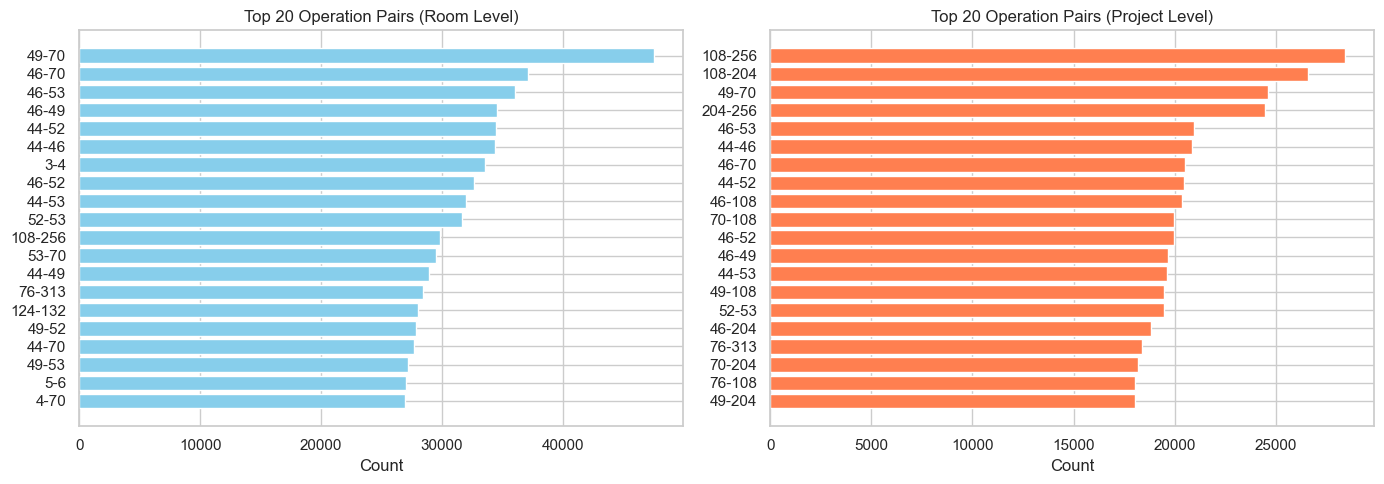

In [8]:
# Room-level co-occurrence
if 'room' in train.columns:
    # Group by project and room
    room_operations = train.groupby(['project_id', 'room'])['work_operation_cluster_code'].apply(lambda x: set(x)).reset_index()
    room_operations.columns = ['project_id', 'room', 'operations']
    
    print(f'Total project-room combinations: {len(room_operations)}')
    
    # Build co-occurrence at room level
    room_cooc_counts = Counter()
    
    for ops in room_operations['operations']:
        if len(ops) > 1:
            pairs = list(combinations(sorted(ops), 2))
            room_cooc_counts.update(pairs)
    
    print(f'Unique operation pairs at room level: {len(room_cooc_counts)}')
    print(f'\nTop 30 most common pairs at room level:')
    top_room_pairs = pd.DataFrame(room_cooc_counts.most_common(30), columns=['pair', 'count'])
    display(top_room_pairs)
    
    # Compare: room-level vs project-level
    # For top pairs, show both counts
    comparison_data = []
    for (op1, op2), room_count in room_cooc_counts.most_common(20):
        proj_count = cooccurrence_counts.get((op1, op2), 0)
        comparison_data.append({
            'op1': op1,
            'op2': op2,
            'room_level_count': room_count,
            'project_level_count': proj_count,
            'ratio': room_count / proj_count if proj_count > 0 else 0
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print('\nComparison: Room-level vs Project-level co-occurrence')
    display(comparison_df)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Room-level
    top_20_room = top_room_pairs.head(20)
    axes[0].barh(range(len(top_20_room)), top_20_room['count'], color='skyblue')
    axes[0].set_yticks(range(len(top_20_room)))
    axes[0].set_yticklabels([f'{p[0]}-{p[1]}' for p in top_20_room['pair']])
    axes[0].set_xlabel('Count')
    axes[0].set_title('Top 20 Operation Pairs (Room Level)')
    axes[0].invert_yaxis()
    
    # Project-level (for comparison)
    top_20_proj = top_pairs.head(20)
    axes[1].barh(range(len(top_20_proj)), top_20_proj['count'], color='coral')
    axes[1].set_yticks(range(len(top_20_proj)))
    axes[1].set_yticklabels([f'{p[0]}-{p[1]}' for p in top_20_proj['pair']])
    axes[1].set_xlabel('Count')
    axes[1].set_title('Top 20 Operation Pairs (Project Level)')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
else:
    print('Room column not found in train data')

## Operation Triplets and Bundles

Find common triplets (3 operations that frequently appear together).

Total unique triplets: 4588675

Top 30 most common triplets:


,triplet,count
0,"(108, 204, 256)",20846
1,"(44, 46, 52)",19723
2,"(44, 46, 53)",19536
3,"(46, 49, 70)",19404
4,"(46, 52, 53)",19275
5,"(44, 52, 53)",19145
6,"(49, 70, 108)",19066
7,"(49, 70, 204)",17515
8,"(46, 53, 70)",16934
9,"(49, 70, 256)",16801


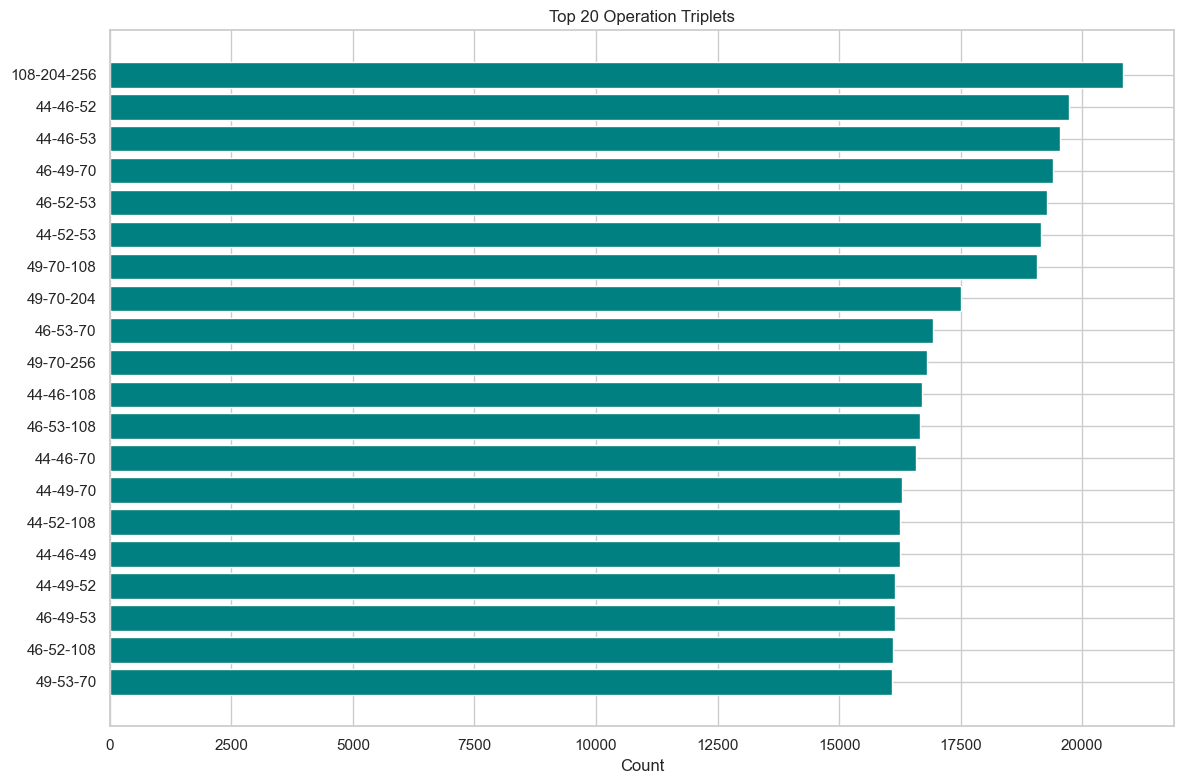


Strong bundles (confidence > 0.8, support > 1%): 79


,op1,op2,op3,count,support,confidence
1461,44,46,52,19723,0.386657,0.943098
1462,44,46,53,19536,0.382991,0.922859
127164,76,313,321,6054,0.118685,0.921742
1783,46,52,53,19275,0.377874,0.921676
1507,44,52,53,19145,0.375326,0.915459
127163,76,313,317,6353,0.124547,0.904213
652859,46,87,91,857,0.016801,0.899265
27147,46,69,73,5309,0.104080,0.895883
68727,154,188,196,646,0.012664,0.886145
127638,313,317,321,5737,0.112470,0.873477


In [9]:
# Find triplets (3 operations that occur together)
triplet_counts = Counter()

for ops in project_operations['operations']:
    if len(ops) >= 3:
        triplets = list(combinations(sorted(ops), 3))
        triplet_counts.update(triplets)

print(f'Total unique triplets: {len(triplet_counts)}')
print(f'\nTop 30 most common triplets:')
top_triplets = pd.DataFrame(triplet_counts.most_common(30), columns=['triplet', 'count'])
display(top_triplets)

# Visualize top triplets
fig, ax = plt.subplots(figsize=(12, 8))
top_20_triplets = top_triplets.head(20)
ax.barh(range(len(top_20_triplets)), top_20_triplets['count'], color='teal')
ax.set_yticks(range(len(top_20_triplets)))
ax.set_yticklabels([f'{t[0]}-{t[1]}-{t[2]}' for t in top_20_triplets['triplet']])
ax.set_xlabel('Count')
ax.set_title('Top 20 Operation Triplets')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Find "bundles": operations that always appear together
# Look for triplets with very high confidence
triplet_metrics = []
for (op1, op2, op3), count in triplet_counts.items():
    # Calculate support
    support = count / total_projects
    
    # Calculate confidence (how often all 3 appear together given individual frequencies)
    min_individual = min(op_counts.get(op1, 1), op_counts.get(op2, 1), op_counts.get(op3, 1))
    confidence = count / min_individual if min_individual > 0 else 0
    
    triplet_metrics.append({
        'op1': op1,
        'op2': op2,
        'op3': op3,
        'count': count,
        'support': support,
        'confidence': confidence
    })

triplet_df = pd.DataFrame(triplet_metrics)
bundles = triplet_df[(triplet_df['confidence'] > 0.8) & (triplet_df['support'] > 0.01)].sort_values('confidence', ascending=False)
print(f'\nStrong bundles (confidence > 0.8, support > 1%): {len(bundles)}')
display(bundles.head(20))

## Conditional Co-occurrence by Metadata

Analyze if co-occurrence patterns differ by project characteristics (insurance company, year, distance).

In [10]:
# Load metadata to enrich analysis
import os
meta_path = '../data/hackathon-recover-x-cogito/metaData.csv'

if os.path.exists(meta_path):
    meta = pd.read_csv(meta_path)
    
    # Merge project operations with metadata
    project_ops_meta = project_operations.merge(meta[['project_id', 'insurance_company', 'case_creation_year', 'office_distance']], 
                                                  on='project_id', how='left')
    
    print('Merged data shape:', project_ops_meta.shape)
    display(project_ops_meta.head())
    
    # Analyze co-occurrence by insurance company
    # For top insurance companies, find their most common operation pairs
    top_companies = meta['insurance_company'].value_counts().head(5).index.tolist()
    
    for company in top_companies:
        company_projects = project_ops_meta[project_ops_meta['insurance_company'] == company]
        company_cooc = Counter()
        
        for ops in company_projects['operations']:
            if len(ops) > 1:
                pairs = list(combinations(sorted(ops), 2))
                company_cooc.update(pairs)
        
        print(f'\n{company}: Top 10 operation pairs')
        top_company_pairs = pd.DataFrame(company_cooc.most_common(10), columns=['pair', 'count'])
        display(top_company_pairs)
    
    # Analyze by year
    print('\n\n=== Co-occurrence patterns by year ===')
    for year in sorted(meta['case_creation_year'].unique())[-5:]:  # last 5 years
        year_projects = project_ops_meta[project_ops_meta['case_creation_year'] == year]
        year_cooc = Counter()
        
        for ops in year_projects['operations']:
            if len(ops) > 1:
                pairs = list(combinations(sorted(ops), 2))
                year_cooc.update(pairs)
        
        print(f'\nYear {year}: Top 10 operation pairs')
        top_year_pairs = pd.DataFrame(year_cooc.most_common(10), columns=['pair', 'count'])
        display(top_year_pairs)
        
else:
    print('metaData.csv not found, skipping conditional analysis')

Merged data shape: (51009, 5)


,project_id,operations,insurance_company,case_creation_year,office_distance
0,147474,"{256, 260, 5, 6, 7, 11, 151, 152, 157, 158, 16...",C,2023,"8,8"
1,147481,"{3, 4, 5, 6, 7, 10, 11, 44, 45, 46, 49, 52, 53...",C,2022,"4,3"
2,147483,"{256, 66, 258, 132, 133, 70, 44, 46, 49, 52, 5...",K,2020,"2,7"
3,147485,"{256, 129, 128, 136, 137, 138, 204, 108, 125, ...",C,2023,7
4,147486,"{256, 288, 2, 3, 386, 358, 263, 296, 294, 10, ...",N,2021,"2,5"



J: Top 10 operation pairs


,pair,count
0,"(108, 256)",9632
1,"(108, 204)",9175
2,"(204, 256)",8432
3,"(49, 70)",6940
4,"(46, 108)",6525
5,"(44, 46)",6400
6,"(108, 112)",6343
7,"(46, 53)",6254
8,"(44, 52)",6179
9,"(46, 52)",6091



C: Top 10 operation pairs


...

,pair,count
0,"(108, 256)",6148
1,"(108, 204)",5479
2,"(204, 256)",4981
3,"(49, 70)",4632
4,"(46, 108)",4169
5,"(46, 53)",4083
6,"(70, 108)",4056
7,"(44, 46)",4015
8,"(44, 52)",4010
9,"(46, 70)",3935



Year 2024: Top 10 operation pairs


,pair,count
0,"(108, 256)",4198
1,"(108, 204)",3786
2,"(204, 256)",3564
3,"(49, 70)",2839
4,"(46, 108)",2804
5,"(76, 108)",2734
6,"(76, 256)",2714
7,"(76, 313)",2714
8,"(256, 313)",2714
9,"(108, 313)",2646



Year 2025: Top 10 operation pairs


,pair,count
0,"(108, 256)",1529
1,"(108, 204)",1434
2,"(204, 256)",1378
3,"(256, 313)",1019
4,"(76, 313)",1011
5,"(76, 108)",1005
6,"(76, 256)",1000
7,"(108, 313)",994
8,"(46, 53)",988
9,"(256, 258)",984


## Summary and Key Insights

Summarize the co-occurrence findings and actionable insights.

In [11]:
# Summary statistics
print('=== CO-OCCURRENCE ANALYSIS SUMMARY ===\n')

print(f'Total projects analyzed: {len(project_operations):,}')
print(f'Total unique operations: {len(op_counts):,}')
print(f'Total unique operation pairs: {len(cooccurrence_counts):,}')
print(f'Total unique operation triplets: {len(triplet_counts):,}')

print(f'\n--- Association Metrics ---')
print(f'Pairs with lift > 1.5: {len(assoc_df[assoc_df["lift"] > 1.5]):,}')
print(f'Pairs with lift > 2.0: {len(assoc_df[assoc_df["lift"] > 2.0]):,}')
print(f'Pairs with support > 5%: {len(assoc_df[assoc_df["support"] > 0.05]):,}')

print(f'\nMean lift score: {assoc_df["lift"].mean():.2f}')
print(f'Median lift score: {assoc_df["lift"].median():.2f}')
print(f'Max lift score: {assoc_df["lift"].max():.2f}')

print(f'\n--- Top 5 Strongest Associations (by lift) ---')
top_5_lift = meaningful.head(5)
for idx, row in top_5_lift.iterrows():
    print(f'  Ops {row["op1"]} ↔ {row["op2"]}: lift={row["lift"]:.2f}, support={row["support"]:.1%}, count={row["cooc_count"]:,}')

print(f'\n--- Top 5 Most Common Pairs (by count) ---')
top_5_count = assoc_df.nlargest(5, 'cooc_count')
for idx, row in top_5_count.iterrows():
    print(f'  Ops {row["op1"]} ↔ {row["op2"]}: count={row["cooc_count"]:,}, support={row["support"]:.1%}, lift={row["lift"]:.2f}')

print(f'\n--- Insights ---')
print('1. Operations with high lift (>2) are strongly associated and likely part of standard workflows.')
print('2. High-count pairs indicate common operation combinations across many projects.')
print('3. Network communities reveal natural groupings of related operations.')
print('4. Room-level analysis shows which operations are done in the same physical space.')
print('5. Triplets/bundles identify sets of operations that consistently occur together.')
print('\n--- Recommendations ---')
print('• Use strong associations (high lift) for operation prediction/recommendation')
print('• Consider bundling frequently co-occurring operations for pricing/estimation')
print('• Identify anomalies: projects missing expected co-occurring operations')
print('• Build conditional models: co-occurrence patterns vary by insurance company and year')

=== CO-OCCURRENCE ANALYSIS SUMMARY ===

Total projects analyzed: 51,009
Total unique operations: 368
Total unique operation pairs: 60,436
Total unique operation triplets: 4,588,675

--- Association Metrics ---
Pairs with lift > 1.5: 24,328
Pairs with lift > 2.0: 16,602
Pairs with support > 5%: 1,726

Mean lift score: 4.95
Median lift score: 1.27
Max lift score: 25504.50

--- Top 5 Strongest Associations (by lift) ---
  Ops 273.0 ↔ 275.0: lift=59.79, support=1.2%, count=599.0
  Ops 193.0 ↔ 195.0: lift=55.30, support=1.5%, count=745.0
  Ops 271.0 ↔ 274.0: lift=49.63, support=1.5%, count=749.0
  Ops 270.0 ↔ 272.0: lift=48.11, support=1.4%, count=722.0
  Ops 96.0 ↔ 344.0: lift=44.89, support=1.3%, count=685.0

--- Top 5 Most Common Pairs (by count) ---
  Ops 108.0 ↔ 256.0: count=28,442.0, support=55.8%, lift=1.10
  Ops 108.0 ↔ 204.0: count=26,603.0, support=52.2%, lift=1.13
  Ops 49.0 ↔ 70.0: count=24,624.0, support=48.3%, lift=1.87
  Ops 204.0 ↔ 256.0: count=24,481.0, support=48.0%, lift=

## Save Results

Save co-occurrence data for downstream modeling.

In [12]:
# Save association metrics
assoc_df.to_csv('../data/hackathon-recover-x-cogito/operation_cooccurrence_pairs.csv', index=False)
print('Saved: operation_cooccurrence_pairs.csv')

# Save triplets
triplet_df.to_csv('../data/hackathon-recover-x-cogito/operation_cooccurrence_triplets.csv', index=False)
print('Saved: operation_cooccurrence_triplets.csv')

# Save strong associations (for modeling)
strong_assoc_save = assoc_df[(assoc_df['lift'] > 2) & (assoc_df['support'] > 0.01)]
strong_assoc_save.to_csv('../data/hackathon-recover-x-cogito/strong_operation_associations.csv', index=False)
print(f'Saved: strong_operation_associations.csv ({len(strong_assoc_save)} pairs)')

print('\nAll co-occurrence analysis results saved!')

Saved: operation_cooccurrence_pairs.csv
Saved: operation_cooccurrence_triplets.csv
Saved: strong_operation_associations.csv (1174 pairs)

All co-occurrence analysis results saved!
Saved: operation_cooccurrence_triplets.csv
Saved: strong_operation_associations.csv (1174 pairs)

All co-occurrence analysis results saved!
